# SGFood233 Data Cleaning & Label Verification

This notebook helps identify problematic images before training:

1. **Corrupt/Invalid Images** — Files that can't be opened
2. **Duplicate Images** — Exact and near-duplicates
3. **Mislabel Detection (Fine-Tuned)** — Using trained vit_small_5epochs predictions
4. **Outlier Detection (Embeddings)** — Images that don't fit their class
5. **Cleanlab Analysis** — Systematic label error detection

**Output:** CSV files of flagged images for manual review

## 0. Setup

In [1]:
# Install additional dependencies for cleaning
# !pip install imagehash cleanlab scikit-learn tqdm

In [2]:
import os
import json
import hashlib
from pathlib import Path
from collections import defaultdict
from typing import List, Dict, Tuple

import torch
import torch.nn.functional as F
import timm
import numpy as np
import pandas as pd
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
# ============================================================
# CONFIGURE YOUR DATASET PATH HERE
# ============================================================
DATASET_ROOT = "../foodsg-233"  # <-- Update this!
OUTPUT_DIR = "cleaning_results"   # Where to save flagged images

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify path exists
if not os.path.exists(DATASET_ROOT):
    raise FileNotFoundError(f"Dataset not found at {DATASET_ROOT}")

print(f"Dataset root: {DATASET_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Dataset root: ../foodsg-233
Output directory: cleaning_results


In [6]:
def get_all_images(root_dir: str, splits: List[str] = ['train', 'valid', 'test']) -> List[Dict]:
    """
    Collect all image paths with their labels.
    Returns list of dicts: {'path': str, 'label': str, 'split': str}
    
    Handles two formats:
    1. Structured: root/split/class/images (e.g., root/train/Apple/img1.jpg)
    2. Raw: root/class/images (e.g., root/Apple/img1.jpg)
    """
    images = []
    valid_extensions = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.gif'}
    
    # Check if structured format exists (has train/val/test folders)
    has_splits = any(os.path.exists(os.path.join(root_dir, split)) for split in splits)
    
    if has_splits:
        # Structured format: root/split/class/images
        for split in splits:
            split_dir = os.path.join(root_dir, split)
            if not os.path.exists(split_dir):
                print(f"Warning: {split_dir} not found, skipping...")
                continue
                
            for class_name in os.listdir(split_dir):
                class_dir = os.path.join(split_dir, class_name)
                if not os.path.isdir(class_dir):
                    continue
                    
                for img_name in os.listdir(class_dir):
                    if Path(img_name).suffix.lower() in valid_extensions:
                        images.append({
                            'path': os.path.join(class_dir, img_name),
                            'label': class_name,
                            'split': split,
                        })
    else:
        # Raw format: root/class/images
        print("Detected raw dataset format (no train/val/test splits)")
        for class_name in os.listdir(root_dir):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
                
            for img_name in os.listdir(class_dir):
                if Path(img_name).suffix.lower() in valid_extensions:
                    images.append({
                        'path': os.path.join(class_dir, img_name),
                        'label': class_name,
                        'split': 'all',  # No split info in raw format
                    })
    
    return images

# Collect all images
all_images = get_all_images(DATASET_ROOT)
print(f"Total images found: {len(all_images)}")

# Count per split
split_counts = defaultdict(int)
for img in all_images:
    split_counts[img['split']] += 1
print(f"Per split: {dict(split_counts)}")

# Count classes
classes = sorted(set(img['label'] for img in all_images))
print(f"Number of classes: {len(classes)}")

Detected raw dataset format (no train/val/test splits)
Total images found: 209808
Per split: {'all': 209808}
Number of classes: 233


---
## 1. Corrupt/Invalid Image Detection

Find images that:
- Can't be opened
- Are truncated/corrupted
- Have invalid formats
- Are too small

In [7]:
def check_image_integrity(image_list: List[Dict], min_size: int = 32) -> pd.DataFrame:
    """
    Check all images for corruption/validity issues.
    
    Args:
        image_list: List of image dicts
        min_size: Minimum dimension (width or height)
    
    Returns:
        DataFrame of problematic images
    """
    issues = []
    
    for img_info in tqdm(image_list, desc="Checking image integrity"):
        path = img_info['path']
        problem = None
        
        try:
            with Image.open(path) as img:
                # Try to load the image data (catches truncated files)
                img.load()
                
                # Check dimensions
                w, h = img.size
                if w < min_size or h < min_size:
                    problem = f"too_small ({w}x{h})"
                
                # Check mode
                if img.mode not in ['RGB', 'RGBA', 'L']:
                    problem = f"unusual_mode ({img.mode})"
                    
        except FileNotFoundError:
            problem = "file_not_found"
        except Image.UnidentifiedImageError:
            problem = "not_an_image"
        except Exception as e:
            problem = f"corrupt ({type(e).__name__})"
        
        if problem:
            issues.append({
                'path': path,
                'label': img_info['label'],
                'split': img_info['split'],
                'issue': problem,
            })
    
    return pd.DataFrame(issues)

# Run integrity check
corrupt_df = check_image_integrity(all_images)
print(f"\nFound {len(corrupt_df)} problematic images")

if len(corrupt_df) > 0:
    print("\nIssue breakdown:")
    print(corrupt_df['issue'].value_counts())
    
    # Save results
    corrupt_df.to_csv(f"{OUTPUT_DIR}/01_corrupt_images.csv", index=False)
    print(f"\nSaved to {OUTPUT_DIR}/01_corrupt_images.csv")

Checking image integrity:   0%|          | 0/209808 [00:00<?, ?it/s]

Checking image integrity:   0%|          | 0/209808 [00:00<?, ?it/s]


Found 0 problematic images


In [8]:
# Preview corrupt images (if any)
if len(corrupt_df) > 0:
    print("Sample of problematic images:")
    display(corrupt_df.head(20))

---
## 2. Duplicate Image Detection

Find:
- **Exact duplicates** — Identical file content
- **Near duplicates** — Perceptually similar images (resized, compressed)

In [4]:
# Install imagehash if needed
try:
    import imagehash
except ImportError:
    !pip install imagehash
    import imagehash

In [10]:
def compute_hashes(image_list: List[Dict]) -> pd.DataFrame:
    """
    Compute MD5 (exact) and perceptual hashes for all images.
    """
    results = []
    
    for img_info in tqdm(image_list, desc="Computing hashes"):
        path = img_info['path']
        md5_hash = None
        phash = None
        
        try:
            # MD5 hash (exact match)
            with open(path, 'rb') as f:
                md5_hash = hashlib.md5(f.read()).hexdigest()
            
            # Perceptual hash (near match)
            with Image.open(path) as img:
                phash = str(imagehash.phash(img))
                
        except Exception as e:
            pass  # Skip problematic files
        
        results.append({
            'path': path,
            'label': img_info['label'],
            'split': img_info['split'],
            'md5': md5_hash,
            'phash': phash,
        })
    
    return pd.DataFrame(results)

# Compute hashes
hash_df = compute_hashes(all_images)
print(f"Computed hashes for {len(hash_df)} images")

Computing hashes:   0%|          | 0/209808 [00:00<?, ?it/s]

Computing hashes:   0%|          | 0/209808 [00:00<?, ?it/s]

Computed hashes for 209808 images


In [11]:
def find_duplicates(hash_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Find exact and near duplicates.
    """
    # Exact duplicates (same MD5)
    md5_counts = hash_df['md5'].value_counts()
    duplicate_md5s = md5_counts[md5_counts > 1].index.tolist()
    exact_dupes = hash_df[hash_df['md5'].isin(duplicate_md5s)].copy()
    exact_dupes = exact_dupes.sort_values('md5')
    
    # Near duplicates (same perceptual hash but different MD5)
    phash_counts = hash_df['phash'].value_counts()
    duplicate_phashes = phash_counts[phash_counts > 1].index.tolist()
    near_dupes = hash_df[hash_df['phash'].isin(duplicate_phashes)].copy()
    # Exclude exact duplicates from near duplicates
    near_dupes = near_dupes[~near_dupes['md5'].isin(duplicate_md5s)]
    near_dupes = near_dupes.sort_values('phash')
    
    return exact_dupes, near_dupes

exact_dupes, near_dupes = find_duplicates(hash_df)

print(f"Exact duplicates: {len(exact_dupes)} images")
print(f"Near duplicates: {len(near_dupes)} images")

Exact duplicates: 4194 images
Near duplicates: 6057 images


In [12]:
# Check for cross-class duplicates (same image, different labels = definite error!)
def find_cross_class_duplicates(dupes_df: pd.DataFrame, hash_col: str) -> pd.DataFrame:
    """Find duplicates that appear in different classes."""
    cross_class = []
    
    for hash_val, group in dupes_df.groupby(hash_col):
        if group['label'].nunique() > 1:
            for _, row in group.iterrows():
                cross_class.append({
                    'path': row['path'],
                    'label': row['label'],
                    'split': row['split'],
                    'hash': hash_val,
                    'all_labels': list(group['label'].unique()),
                })
    
    return pd.DataFrame(cross_class)

# Cross-class exact duplicates
cross_exact = find_cross_class_duplicates(exact_dupes, 'md5')
cross_near = find_cross_class_duplicates(hash_df[hash_df['phash'].notna()], 'phash')

print(f"\n⚠️  Cross-class EXACT duplicates: {len(cross_exact)} images")
print(f"⚠️  Cross-class NEAR duplicates: {len(cross_near)} images")

if len(cross_exact) > 0:
    print("\nThese are DEFINITE labeling errors (same image in different classes):")
    display(cross_exact.head(20))


⚠️  Cross-class EXACT duplicates: 4164 images
⚠️  Cross-class NEAR duplicates: 5713 images

These are DEFINITE labeling errors (same image in different classes):


,path,label,split,hash,all_labels
0,../foodsg-233\fried prawn\YP7VELY1NL1C9GW3DL7Y...,fried prawn,all,0038131090b92a89ac784e1193989585,"[fried prawn, Mee siam, fried]"
1,"../foodsg-233\Mee siam, fried\2YHRX7HX3DJT5KR9...","Mee siam, fried",all,0038131090b92a89ac784e1193989585,"[fried prawn, Mee siam, fried]"
2,../foodsg-233\drunken prawn\RRUZLAKZHWJRNI9U4H...,drunken prawn,all,00a83cef02fddcd966584ebf4ac30034,"[drunken prawn, fried prawn]"
3,../foodsg-233\fried prawn\XAYA1T2YDMRESWV6OY61...,fried prawn,all,00a83cef02fddcd966584ebf4ac30034,"[drunken prawn, fried prawn]"
4,../foodsg-233\Laksa\W2OGIHH7P7N51390W4CIJU99.jpg,Laksa,all,00c5f1c1c67072ec9468769b0899498f,"[Laksa, chicken soup]"
5,../foodsg-233\chicken soup\UBJAPZYFJPMUQHVVRLO...,chicken soup,all,00c5f1c1c67072ec9468769b0899498f,"[Laksa, chicken soup]"
6,../foodsg-233\bee hoon\PLN79BA678ZEH6JJ64MYJ6J...,bee hoon,all,00c73e299ac03bb2ae16efb53d1b7f02,"[bee hoon, Seafood Noodles Soup]"
7,../foodsg-233\Seafood Noodles Soup\IFZLFZS9V2E...,Seafood Noodles Soup,all,00c73e299ac03bb2ae16efb53d1b7f02,"[bee hoon, Seafood Noodles Soup]"
8,../foodsg-233\chai tow kuay\2ZGCLZF1J0022GZ5GU...,chai tow kuay,all,00dcdfa1815f1468a6a4226f9cb7aefa,"[chai tow kuay, Kway Teow]"
9,../foodsg-233\Kway Teow\QZQISL5E9QX2OPK6JO8BCW...,Kway Teow,all,00dcdfa1815f1468a6a4226f9cb7aefa,"[chai tow kuay, Kway Teow]"


In [13]:
# Save duplicate reports
if len(exact_dupes) > 0:
    exact_dupes.to_csv(f"{OUTPUT_DIR}/02a_exact_duplicates.csv", index=False)
    print(f"Saved exact duplicates to {OUTPUT_DIR}/02a_exact_duplicates.csv")

if len(near_dupes) > 0:
    near_dupes.to_csv(f"{OUTPUT_DIR}/02b_near_duplicates.csv", index=False)
    print(f"Saved near duplicates to {OUTPUT_DIR}/02b_near_duplicates.csv")

if len(cross_exact) > 0 or len(cross_near) > 0:
    cross_all = pd.concat([cross_exact, cross_near]).drop_duplicates(subset='path')
    cross_all.to_csv(f"{OUTPUT_DIR}/02c_cross_class_duplicates.csv", index=False)
    print(f"Saved cross-class duplicates to {OUTPUT_DIR}/02c_cross_class_duplicates.csv")

Saved exact duplicates to cleaning_results/02a_exact_duplicates.csv
Saved near duplicates to cleaning_results/02b_near_duplicates.csv
Saved cross-class duplicates to cleaning_results/02c_cross_class_duplicates.csv


Sample exact duplicate groups:


Sample exact duplicate groups:


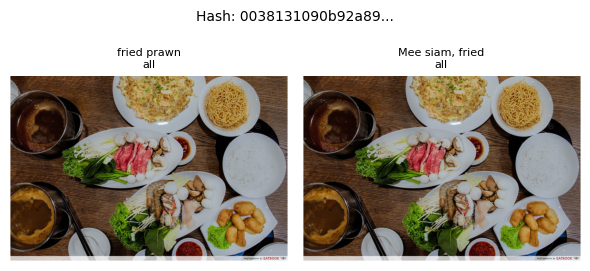

Sample exact duplicate groups:


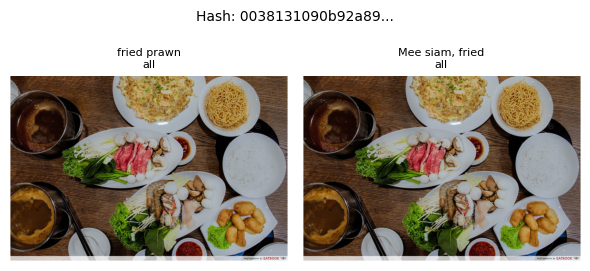

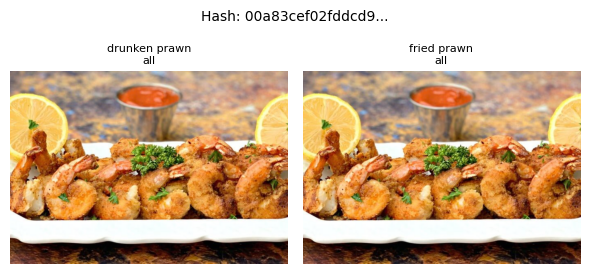

In [14]:
# Visualize some duplicates
def show_duplicate_group(dupes_df: pd.DataFrame, hash_col: str, n_groups: int = 3):
    """Display groups of duplicate images."""
    hash_values = dupes_df[hash_col].unique()[:n_groups]
    
    for hash_val in hash_values:
        group = dupes_df[dupes_df[hash_col] == hash_val]
        n_images = min(len(group), 5)
        
        fig, axes = plt.subplots(1, n_images, figsize=(3*n_images, 3))
        if n_images == 1:
            axes = [axes]
        
        for ax, (_, row) in zip(axes, group.head(5).iterrows()):
            try:
                img = Image.open(row['path'])
                ax.imshow(img)
                ax.set_title(f"{row['label']}\n{row['split']}", fontsize=8)
            except:
                ax.text(0.5, 0.5, 'Error', ha='center')
            ax.axis('off')
        
        plt.suptitle(f"Hash: {hash_val[:16]}...", fontsize=10)
        plt.tight_layout()
        plt.show()

if len(exact_dupes) > 0:
    print("Sample exact duplicate groups:")
    show_duplicate_group(exact_dupes, 'md5', n_groups=2)

---
## 3. Mislabel Detection Using Fine-Tuned Model

Use your trained vit_small_5epochs model to detect potential mislabels. Flag images where:
- Model confidently predicts a different class (likely mislabel)
- Model has very low confidence (ambiguous/unclear image)

In [15]:
# Load fine-tuned SGFood233 model
# Using vit_small_5epochs trained on SGFood233 dataset
import warnings
warnings.filterwarnings("ignore", message="load_learner")

from fastai.vision.all import load_learner

learn = load_learner("../foodsg233_fastai_dataset/vit_small_5epochs.pkl")
model = learn.model.to(device)
model.eval()

# Get SGFood233 class names from the trained model
sgfood_labels = list(learn.dls.vocab)
print(f"Loaded fine-tuned model with {len(sgfood_labels)} SGFood233 classes")
print(f"First 10 classes: {sgfood_labels[:10]}")

Loaded fine-tuned model with 233 SGFood233 classes
First 10 classes: ['Alcoholic Beverage', 'Apple', 'Apricot', 'Avocados', 'Ban Mian', 'Barley', 'Bee hoon, goreng', 'Bee hoon, soto', 'Bibimbap', 'Blackberry']


In [16]:
# Define transforms
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SimpleImageDataset(Dataset):
    def __init__(self, image_list, transform):
        self.images = image_list
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_info = self.images[idx]
        try:
            img = Image.open(img_info['path']).convert('RGB')
            img = self.transform(img)
            return img, idx
        except:
            # Return a blank image for corrupt files
            return torch.zeros(3, 224, 224), idx

In [17]:
@torch.no_grad()
def get_predictions(model, image_list, batch_size=64):
    """
    Get model predictions for all images.
    """
    dataset = SimpleImageDataset(image_list, val_transforms)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    all_probs = []
    all_preds = []
    all_indices = []
    
    for images, indices in tqdm(loader, desc="Getting predictions"):
        images = images.to(device)
        logits = model(images)
        probs = F.softmax(logits, dim=1)
        
        max_probs, preds = probs.max(dim=1)
        
        all_probs.extend(max_probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_indices.extend(indices.numpy())
    
    return np.array(all_probs), np.array(all_preds), np.array(all_indices)

# Get predictions
probs, preds, indices = get_predictions(model, all_images)

Getting predictions:   0%|          | 0/3279 [00:00<?, ?it/s]

In [18]:
# Create predictions dataframe
pred_df = pd.DataFrame([
    {
        'path': all_images[idx]['path'],
        'label': all_images[idx]['label'],
        'split': all_images[idx]['split'],
        'pred_class': sgfood_labels[pred],
        'confidence': prob,
    }
    for idx, pred, prob in zip(indices, preds, probs)
])

print(f"Predictions for {len(pred_df)} images")
print(f"\nConfidence distribution:")
print(pred_df['confidence'].describe())

Predictions for 209808 images

Confidence distribution:
count    209808.000000
mean          0.706704
std           0.280025
min           0.041524
25%           0.467829
50%           0.790703
75%           0.975986
max           0.999999
Name: confidence, dtype: float64


In [19]:
# Flag low confidence images (model is unsure)
LOW_CONF_THRESHOLD = 0.3

low_conf_df = pred_df[pred_df['confidence'] < LOW_CONF_THRESHOLD].copy()
low_conf_df['flag_reason'] = 'low_confidence'

print(f"Low confidence images (<{LOW_CONF_THRESHOLD}): {len(low_conf_df)}")

Low confidence images (<0.3): 24814


In [20]:
# Flag images where predicted class differs from given label with high confidence
# These are likely mislabels since the model was trained on the same dataset
HIGH_CONF_THRESHOLD = 0.7

# Find confident disagreements between model prediction and given label
mislabel_df = pred_df[
    (pred_df['confidence'] > HIGH_CONF_THRESHOLD) & 
    (pred_df['pred_class'] != pred_df['label'])
].copy()
mislabel_df['flag_reason'] = 'confident_disagreement'

print(f"High confidence disagreements (pred ≠ label): {len(mislabel_df)}")
if len(mislabel_df) > 0:
    print("\nMost common confusion pairs:")
    confusion_pairs = mislabel_df.groupby(['label', 'pred_class']).size().sort_values(ascending=False)
    print(confusion_pairs.head(10))

High confidence disagreements (pred ≠ label): 10394

Most common confusion pairs:
label             pred_class       
Sweets            Chocolate            149
char siew pau     steamed buns         113
Chocolate         Sweets               107
Nuts              Chocolate             95
Fruit juice       singapore sling       86
biscuit           Chocolate             86
whole wheat       whole grain bread     81
Pomelo            Grapefruit            80
cream soup        mushroom soup         70
Snacks and Chips  Sweets                68
dtype: int64


In [21]:
# Combine and save
pretrained_flags = pd.concat([low_conf_df, mislabel_df]).drop_duplicates(subset='path')

if len(pretrained_flags) > 0:
    pretrained_flags.to_csv(f"{OUTPUT_DIR}/03_finetuned_model_flags.csv", index=False)
    print(f"\nSaved {len(pretrained_flags)} flagged images to {OUTPUT_DIR}/03_finetuned_model_flags.csv")


Saved 35208 flagged images to cleaning_results/03_finetuned_model_flags.csv


Samples with confident disagreement (likely mislabels):


Samples with confident disagreement (likely mislabels):


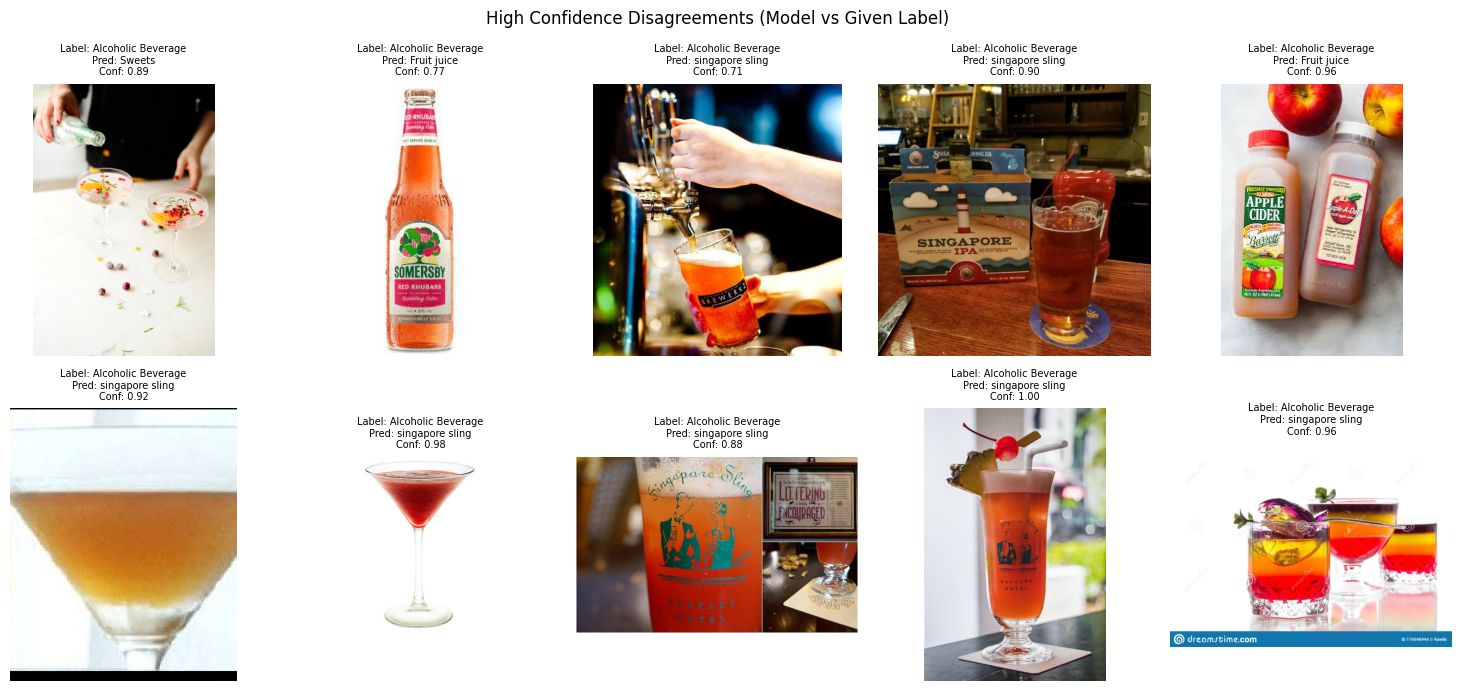

Samples with confident disagreement (likely mislabels):


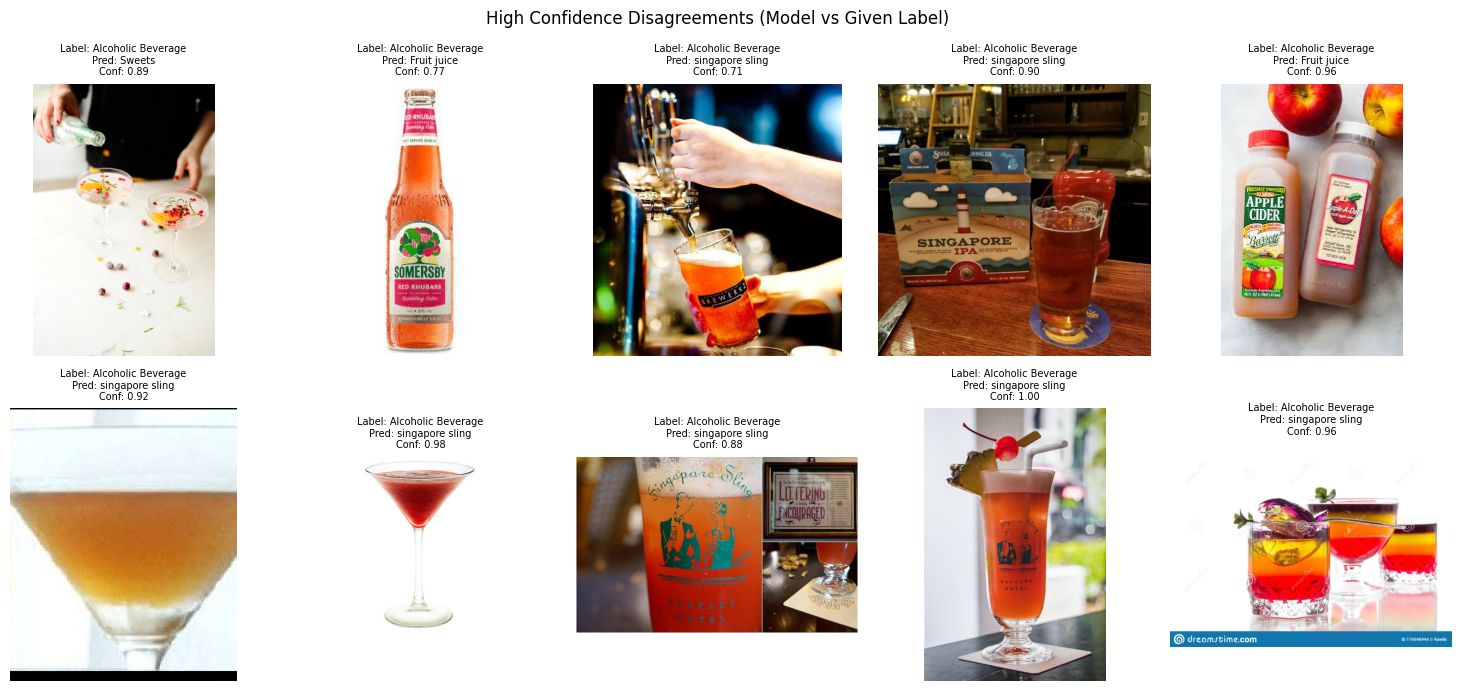


Samples with low confidence:


Samples with confident disagreement (likely mislabels):


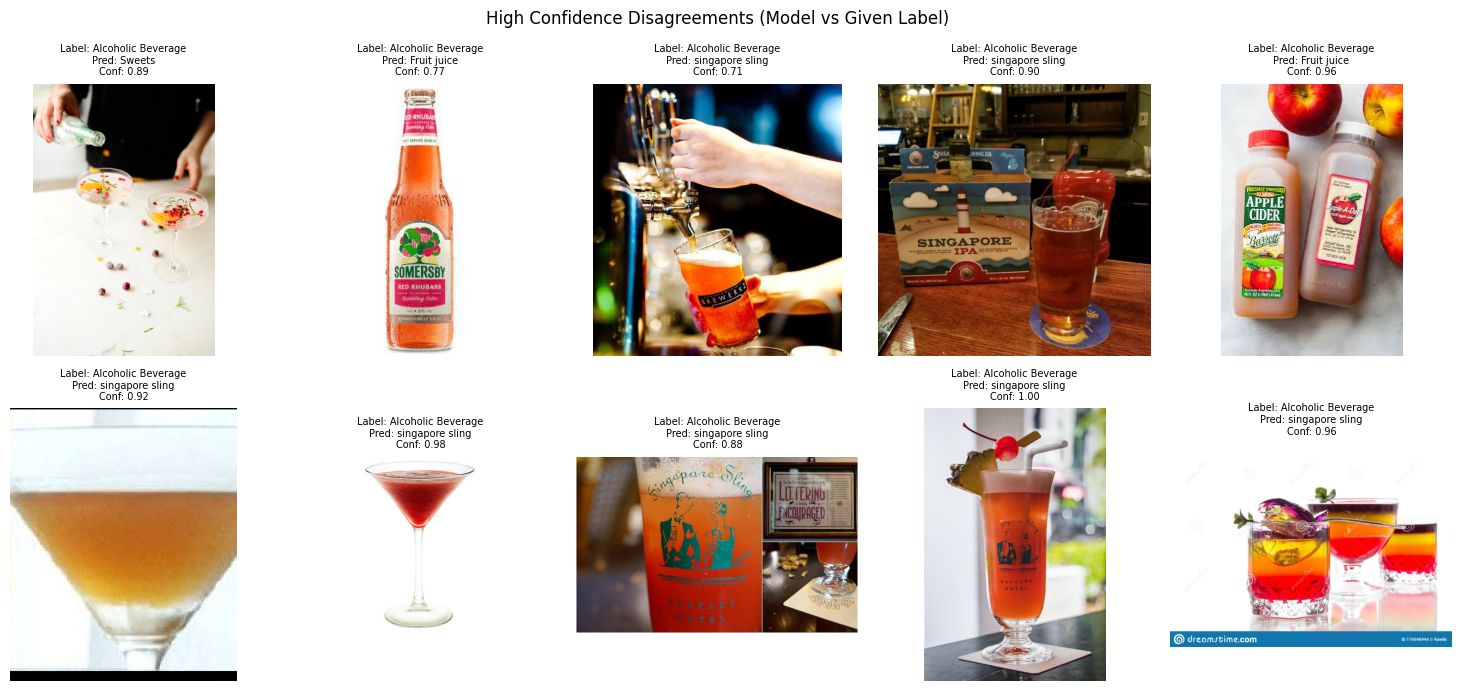


Samples with low confidence:


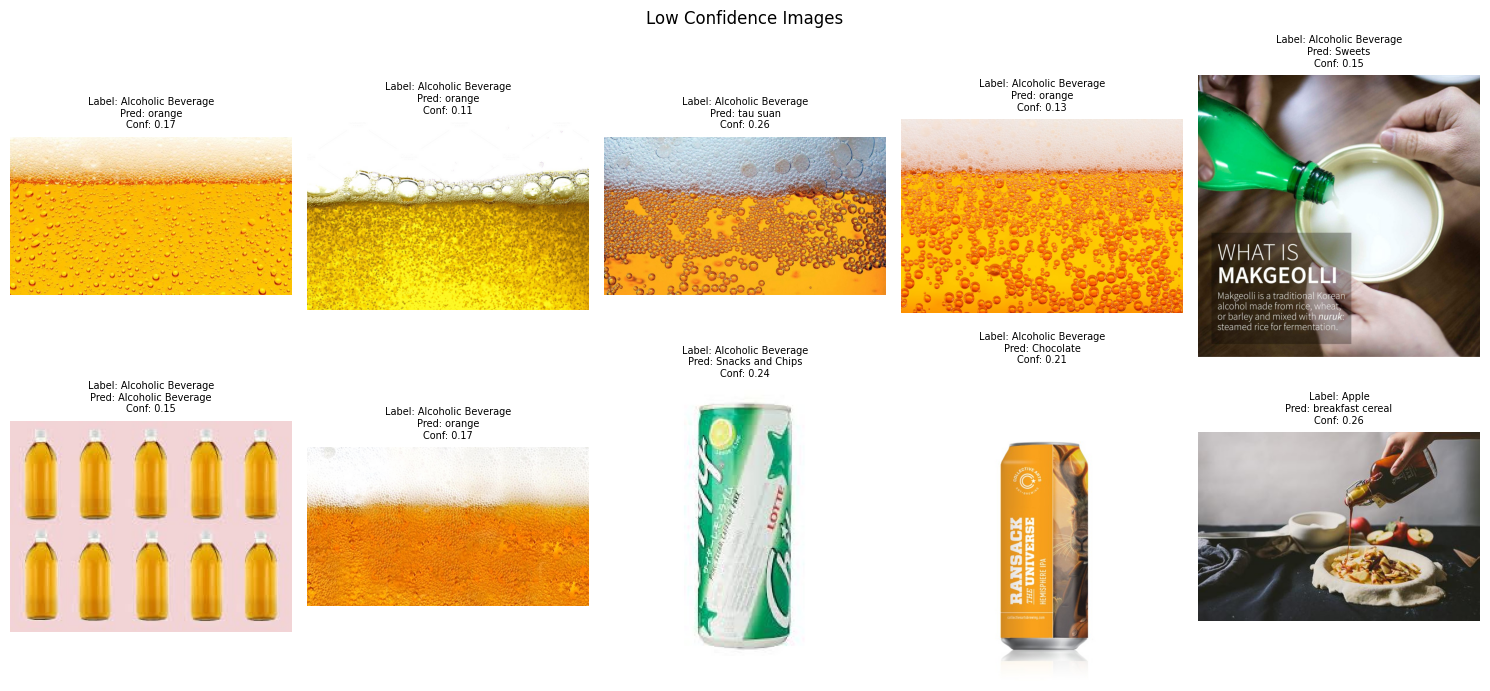

In [22]:
# Visualize some flagged images
def show_flagged_images(df: pd.DataFrame, title: str, n: int = 10):
    """Display flagged images."""
    sample = df.head(n)
    n_show = len(sample)
    
    cols = min(5, n_show)
    rows = (n_show + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3.5*rows))
    axes = np.array(axes).flatten() if n_show > 1 else [axes]
    
    for ax, (_, row) in zip(axes, sample.iterrows()):
        try:
            img = Image.open(row['path'])
            ax.imshow(img)
            ax.set_title(f"Label: {row['label']}\nPred: {row['pred_class'][:20]}\nConf: {row['confidence']:.2f}", fontsize=7)
        except:
            ax.text(0.5, 0.5, 'Error', ha='center')
        ax.axis('off')
    
    # Hide empty subplots
    for ax in axes[n_show:]:
        ax.axis('off')
    
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

if len(mislabel_df) > 0:
    print("Samples with confident disagreement (likely mislabels):")
    show_flagged_images(mislabel_df, "High Confidence Disagreements (Model vs Given Label)")

if len(low_conf_df) > 0:
    print("\nSamples with low confidence:")
    show_flagged_images(low_conf_df, "Low Confidence Images")

---
## 4. Outlier Detection Using Embeddings

Extract feature embeddings and find images that don't fit their class:
- Per-class outlier detection using Isolation Forest
- Images far from their class centroid

In [23]:
# Use the trained model as feature extractor (remove classification head)
# Extract features from the layer before final classification
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])  # Remove final layer
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# Check embedding dimension
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    dummy_out = feature_extractor(dummy)
    # Flatten if needed
    if len(dummy_out.shape) > 2:
        embed_dim = dummy_out.flatten(1).shape[1]
    else:
        embed_dim = dummy_out.shape[1]
print(f"Embedding dimension: {embed_dim}")

Embedding dimension: 384


In [24]:
@torch.no_grad()
def extract_embeddings(model, image_list, batch_size=64):
    """
    Extract feature embeddings for all images.
    """
    dataset = SimpleImageDataset(image_list, val_transforms)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    all_embeddings = []
    all_indices = []
    
    for images, indices in tqdm(loader, desc="Extracting embeddings"):
        images = images.to(device)
        embeddings = model(images)
        
        # Flatten embeddings if needed
        if len(embeddings.shape) > 2:
            embeddings = embeddings.flatten(1)
        
        all_embeddings.append(embeddings.cpu().numpy())
        all_indices.extend(indices.numpy())
    
    return np.vstack(all_embeddings), np.array(all_indices)

# Extract embeddings
embeddings, embed_indices = extract_embeddings(feature_extractor, all_images)
print(f"Extracted embeddings: {embeddings.shape}")

Extracting embeddings:   0%|          | 0/3279 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/3279 [00:00<?, ?it/s]

Extracted embeddings: (209808, 384)


In [25]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def detect_outliers_per_class(embeddings, image_list, indices, contamination=0.05):
    """
    Detect outliers within each class using Isolation Forest.
    
    Args:
        contamination: Expected proportion of outliers (0.05 = 5%)
    """
    outliers = []
    
    # Group by class
    class_indices = defaultdict(list)
    for i, idx in enumerate(indices):
        label = image_list[idx]['label']
        class_indices[label].append(i)
    
    for class_name, idx_list in tqdm(class_indices.items(), desc="Detecting outliers"):
        if len(idx_list) < 20:  # Skip small classes
            continue
        
        # Get embeddings for this class
        class_embeddings = embeddings[idx_list]
        
        # Normalize
        scaler = StandardScaler()
        class_embeddings_scaled = scaler.fit_transform(class_embeddings)
        
        # Fit Isolation Forest
        iso_forest = IsolationForest(
            contamination=contamination,
            random_state=42,
            n_jobs=-1
        )
        predictions = iso_forest.fit_predict(class_embeddings_scaled)
        scores = iso_forest.score_samples(class_embeddings_scaled)
        
        # Collect outliers (prediction = -1)
        for i, (pred, score) in enumerate(zip(predictions, scores)):
            if pred == -1:
                orig_idx = indices[idx_list[i]]
                outliers.append({
                    'path': image_list[orig_idx]['path'],
                    'label': image_list[orig_idx]['label'],
                    'split': image_list[orig_idx]['split'],
                    'outlier_score': score,
                })
    
    return pd.DataFrame(outliers)

# Detect outliers
outlier_df = detect_outliers_per_class(embeddings, all_images, embed_indices, contamination=0.03)
print(f"\nDetected {len(outlier_df)} outliers")

Detecting outliers:   0%|          | 0/233 [00:00<?, ?it/s]

Detecting outliers:   0%|          | 0/233 [00:00<?, ?it/s]


Detected 6402 outliers


In [26]:
# Save outliers
if len(outlier_df) > 0:
    outlier_df = outlier_df.sort_values('outlier_score')
    outlier_df.to_csv(f"{OUTPUT_DIR}/04_embedding_outliers.csv", index=False)
    print(f"Saved outliers to {OUTPUT_DIR}/04_embedding_outliers.csv")
    
    print("\nClasses with most outliers:")
    print(outlier_df['label'].value_counts().head(10))

Saved outliers to cleaning_results/04_embedding_outliers.csv

Classes with most outliers:
label
Chocolate           151
Snacks and Chips     89
biscuit              88
Sweets               80
Fruit juice          65
Udon                 57
rock melon           55
popcorn              55
spring rolls         54
dumpling             53
Name: count, dtype: int64


Most extreme outliers (lowest scores = most unusual):


Most extreme outliers (lowest scores = most unusual):


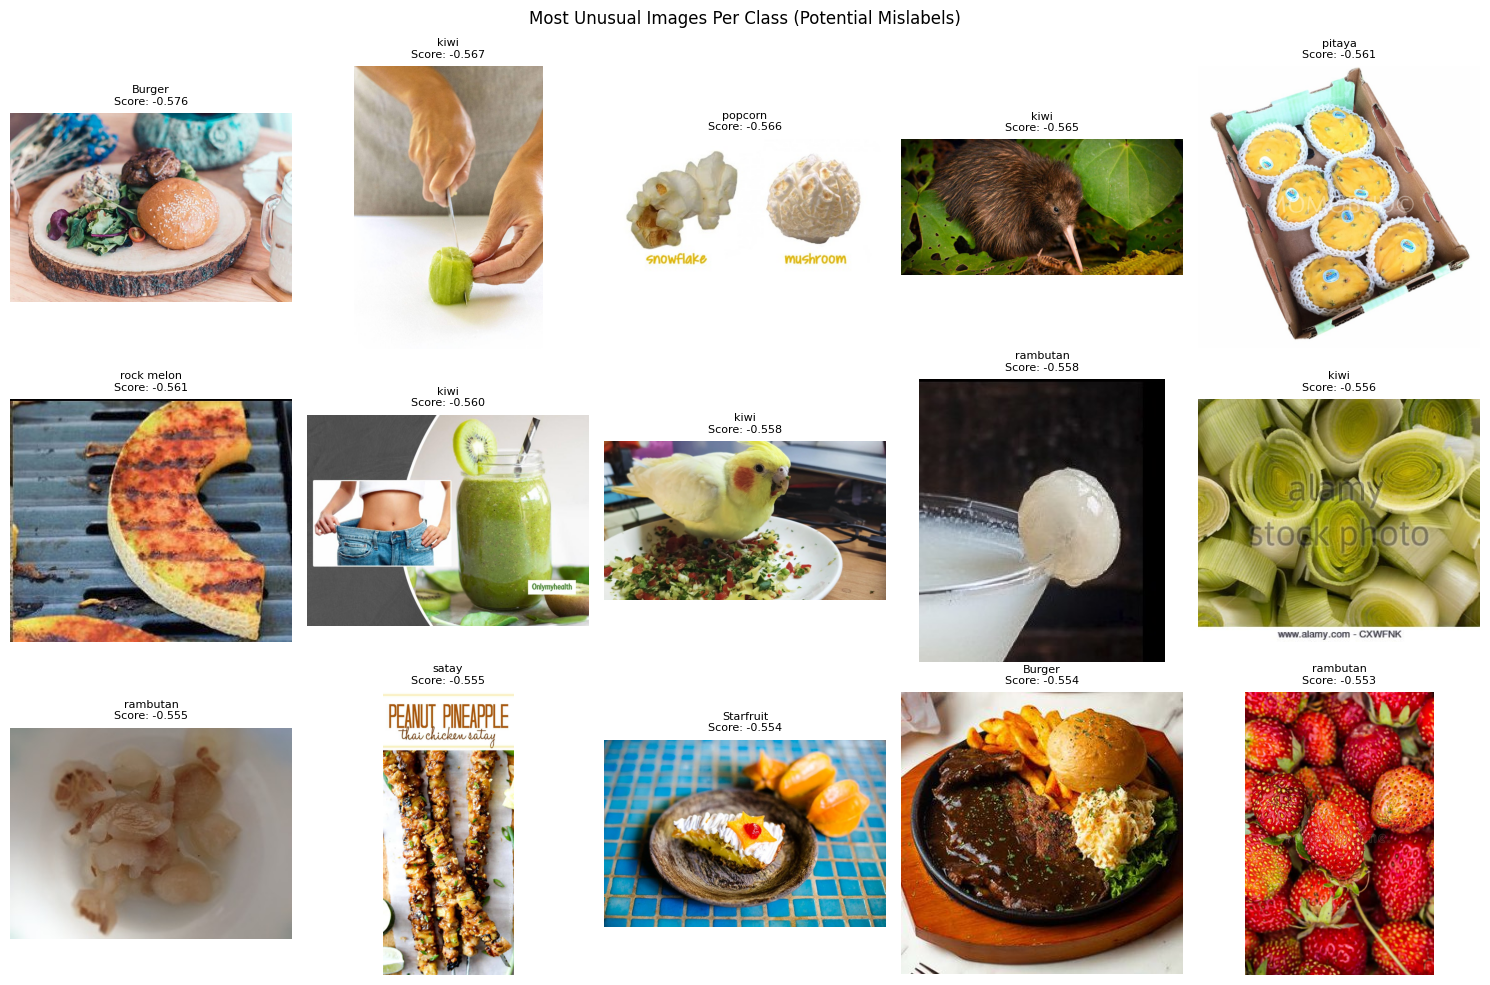

In [27]:
# Visualize worst outliers
if len(outlier_df) > 0:
    print("Most extreme outliers (lowest scores = most unusual):")
    worst_outliers = outlier_df.head(15)
    
    cols = 5
    rows = 3
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
    axes = axes.flatten()
    
    for ax, (_, row) in zip(axes, worst_outliers.iterrows()):
        try:
            img = Image.open(row['path'])
            ax.imshow(img)
            ax.set_title(f"{row['label']}\nScore: {row['outlier_score']:.3f}", fontsize=8)
        except:
            ax.text(0.5, 0.5, 'Error', ha='center')
        ax.axis('off')
    
    plt.suptitle("Most Unusual Images Per Class (Potential Mislabels)", fontsize=12)
    plt.tight_layout()
    plt.show()

---
## 5. Cleanlab Analysis (Confident Learning)

Cleanlab uses confident learning to find label errors by analyzing model predictions and identifying:
- Out-of-distribution examples
- Label errors based on cross-validation confidence

In [28]:
# Install cleanlab if needed
try:
    import cleanlab
    from cleanlab.filter import find_label_issues
except ImportError:
    !pip install cleanlab
    import cleanlab
    from cleanlab.filter import find_label_issues

print(f"Cleanlab version: {cleanlab.__version__}")

     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ----------- ---------------------------- 4.5/15.8 MB 23.3 MB/s eta 0:00:01
     ----------------------------- --------- 12.1/15.8 MB 29.5 MB/s eta 0:00:01
     ---------------------------------------- 15.8/15.8 MB 29.9 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
Using cached termcolor-3.2.0-py3-none-any.whl (7.7 kB)
  Created wheel for numpy: filename=numpy-1.26.4-cp313-cp313-win_amd64.whl size=6107033 sha256=5db61ee292ab475a9f8f7ba5287755fc5a54b5

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.5.3 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
     ----------- ---------------------------- 4.5/15.8 MB 23.3 MB/s eta 0:00:01
     ----------------------------- --------- 12.1/15.8 MB 29.5 MB/s eta 0:00:01
     ---------------------------------------- 15.8/15.8 MB 29.9 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
Using cached termcolor-3.2.0-py3-none-any.whl (7.7 kB)
  Created wheel for numpy: filename=numpy-1.26.4-cp313-cp313-win_amd64.whl size=6107033 sha256=5db61ee292ab475a9f8f7ba5287755fc5a54b5

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.5.3 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Cleanlab version: 2.7.1


In [29]:
# For Cleanlab, we need predicted probabilities for all classes
# We'll train a simple classifier on SGFood233 classes using the embeddings

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

# Create label encoder
label_to_idx = {label: idx for idx, label in enumerate(classes)}
labels = np.array([label_to_idx[all_images[idx]['label']] for idx in embed_indices])

print(f"Training classifier on {len(classes)} classes...")
print(f"Samples: {len(labels)}")

Training classifier on 233 classes...
Samples: 209808


In [30]:
# Get cross-validated predicted probabilities
# This is what Cleanlab needs to detect label errors

print("Computing cross-validated probabilities (this may take a while)...")

clf = LogisticRegression(
    max_iter=500,
    solver='lbfgs',
    multi_class='multinomial',
    n_jobs=-1,
    random_state=42
)

# Use 3-fold CV for speed (Cleanlab recommends 5-10 for accuracy)
pred_probs = cross_val_predict(
    clf, 
    embeddings, 
    labels, 
    cv=3, 
    method='predict_proba',
    n_jobs=-1
)

print(f"Predicted probabilities shape: {pred_probs.shape}")

Computing cross-validated probabilities (this may take a while)...


Computing cross-validated probabilities (this may take a while)...


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
# Find label issues using Cleanlab
print("Finding label issues...")

label_issues = find_label_issues(
    labels=labels,
    pred_probs=pred_probs,
    return_indices_ranked_by='self_confidence',  # Rank by how confident model is in given label
)

print(f"\nCleanlab found {len(label_issues)} potential label issues")

In [ ]:
# Create detailed report
idx_to_label = {v: k for k, v in label_to_idx.items()}

cleanlab_results = []
for issue_idx in label_issues:
    orig_idx = embed_indices[issue_idx]
    given_label = labels[issue_idx]
    pred_label = pred_probs[issue_idx].argmax()
    given_prob = pred_probs[issue_idx, given_label]
    pred_prob = pred_probs[issue_idx, pred_label]
    
    cleanlab_results.append({
        'path': all_images[orig_idx]['path'],
        'split': all_images[orig_idx]['split'],
        'given_label': idx_to_label[given_label],
        'predicted_label': idx_to_label[pred_label],
        'given_label_confidence': given_prob,
        'predicted_label_confidence': pred_prob,
        'confidence_gap': pred_prob - given_prob,
    })

cleanlab_df = pd.DataFrame(cleanlab_results)
cleanlab_df = cleanlab_df.sort_values('confidence_gap', ascending=False)

print(f"\nTop suspected mislabels:")
display(cleanlab_df.head(20))

In [ ]:
# Save Cleanlab results
cleanlab_df.to_csv(f"{OUTPUT_DIR}/05_cleanlab_label_issues.csv", index=False)
print(f"Saved {len(cleanlab_df)} label issues to {OUTPUT_DIR}/05_cleanlab_label_issues.csv")

In [ ]:
# Visualize most confident mislabels
print("Most confident predicted mislabels:")
top_issues = cleanlab_df.head(15)

cols = 5
rows = 3
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
axes = axes.flatten()

for ax, (_, row) in zip(axes, top_issues.iterrows()):
    try:
        img = Image.open(row['path'])
        ax.imshow(img)
        ax.set_title(
            f"Given: {row['given_label'][:15]}\n"
            f"Pred: {row['predicted_label'][:15]}\n"
            f"Gap: {row['confidence_gap']:.2f}",
            fontsize=7
        )
    except:
        ax.text(0.5, 0.5, 'Error', ha='center')
    ax.axis('off')

plt.suptitle("Cleanlab: Most Likely Mislabeled Images", fontsize=12)
plt.tight_layout()
plt.show()

---
## 6. Summary Report

In [31]:
# Combine all flagged images
all_flags = []

# 1. Corrupt images
if len(corrupt_df) > 0:
    corrupt_flags = corrupt_df[['path', 'label', 'split']].copy()
    corrupt_flags['flag_type'] = 'corrupt'
    corrupt_flags['priority'] = 'HIGH'
    all_flags.append(corrupt_flags)

# 2. Cross-class duplicates (definite errors)
if 'cross_all' in dir() and len(cross_all) > 0:
    cross_flags = cross_all[['path', 'label', 'split']].copy()
    cross_flags['flag_type'] = 'cross_class_duplicate'
    cross_flags['priority'] = 'HIGH'
    all_flags.append(cross_flags)

# 3. Fine-tuned model flags (disagreements + low confidence)
if len(pretrained_flags) > 0:
    pt_flags = pretrained_flags[['path', 'label', 'split']].copy()
    pt_flags['flag_type'] = 'finetuned_model'
    pt_flags['priority'] = 'HIGH'  # High priority since model knows SGFood233 classes
    all_flags.append(pt_flags)

# 4. Embedding outliers
if len(outlier_df) > 0:
    outlier_flags = outlier_df[['path', 'label', 'split']].copy()
    outlier_flags['flag_type'] = 'embedding_outlier'
    outlier_flags['priority'] = 'MEDIUM'
    all_flags.append(outlier_flags)

# # 5. Cleanlab issues (top 10%)
# if len(cleanlab_df) > 0:
#     top_cleanlab = cleanlab_df.head(int(len(cleanlab_df) * 0.1))
#     cl_flags = top_cleanlab[['path', 'split']].copy()
#     cl_flags['label'] = top_cleanlab['given_label']
#     cl_flags['flag_type'] = 'cleanlab_mislabel'
#     cl_flags['priority'] = 'MEDIUM'
#     all_flags.append(cl_flags)

# Combine and deduplicate
if all_flags:
    combined_df = pd.concat(all_flags, ignore_index=True)
    combined_df = combined_df.drop_duplicates(subset='path', keep='first')
    combined_df = combined_df.sort_values(['priority', 'flag_type'])
    
    combined_df.to_csv(f"{OUTPUT_DIR}/00_COMBINED_FLAGS.csv", index=False)
    print(f"Combined flagged images saved to {OUTPUT_DIR}/00_COMBINED_FLAGS.csv")
else:
    combined_df = pd.DataFrame()

Combined flagged images saved to cleaning_results/00_COMBINED_FLAGS.csv


In [33]:
# Print summary
print("="*60)
print("DATA CLEANING SUMMARY")
print("="*60)
print(f"\nTotal images scanned: {len(all_images):,}")
print(f"\nIssues found:")
print(f"  • Corrupt/invalid images:      {len(corrupt_df):,}")
print(f"  • Exact duplicates:            {len(exact_dupes):,}")
print(f"  • Near duplicates:             {len(near_dupes):,}")
print(f"  • Cross-class duplicates:      {len(cross_all) if 'cross_all' in dir() else 0:,}  ⚠️  (Definite errors!)")
print(f"  • Fine-tuned model flags:      {len(pretrained_flags):,}  (SGFood233-specific)")
print(f"  • Embedding outliers:          {len(outlier_df):,}")
# print(f"  • Cleanlab label issues:       {len(cleanlab_df):,}")
print(f"\n  → Total unique flagged images: {len(combined_df):,}")
print(f"  → Percentage of dataset:       {100*len(combined_df)/len(all_images):.1f}%")
print("\n" + "="*60)
print("PRIORITY REVIEW ORDER:")
print("="*60)
print("1. HIGH:   Cross-class duplicates (definite errors)")
print("2. HIGH:   Corrupt images (must fix or remove)")
print("3. HIGH:   Fine-tuned model disagreements (likely mislabels)")
print("4. MEDIUM: Cleanlab mislabels (cross-validated predictions)")
print("5. MEDIUM: Embedding outliers (unusual for their class)")
print("\nOutput files saved to:", OUTPUT_DIR)

DATA CLEANING SUMMARY

Total images scanned: 209,808

Issues found:
  • Corrupt/invalid images:      0
  • Exact duplicates:            4,194
  • Near duplicates:             6,057
  • Cross-class duplicates:      5,713  ⚠️  (Definite errors!)
  • Fine-tuned model flags:      35,208  (SGFood233-specific)
  • Embedding outliers:          6,402

  → Total unique flagged images: 42,250
  → Percentage of dataset:       20.1%

PRIORITY REVIEW ORDER:
1. HIGH:   Cross-class duplicates (definite errors)
2. HIGH:   Corrupt images (must fix or remove)
3. HIGH:   Fine-tuned model disagreements (likely mislabels)
4. MEDIUM: Cleanlab mislabels (cross-validated predictions)
5. MEDIUM: Embedding outliers (unusual for their class)

Output files saved to: cleaning_results


In [34]:
# List all output files
print("\nGenerated files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(path)
    if f.endswith('.csv'):
        df = pd.read_csv(path)
        print(f"  {f}: {len(df)} rows")


Generated files:
  00_COMBINED_FLAGS.csv: 42250 rows
  02a_exact_duplicates.csv: 4194 rows
  02b_near_duplicates.csv: 6057 rows
  02c_cross_class_duplicates.csv: 5713 rows
  03_finetuned_model_flags.csv: 35208 rows
  04_embedding_outliers.csv: 6402 rows


---
## 7. Optional: Manual Review Helper

Run this to step through flagged images one by one.

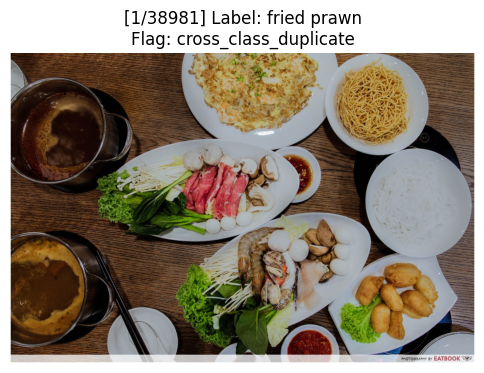

Path: ../foodsg-233\fried prawn\YP7VELY1NL1C9GW3DL7YWISA.jpg

Options: [k]eep, [r]emove, [m]ove to correct class, [s]kip, [q]uit
Stopped at index 0


In [35]:
def review_images(df: pd.DataFrame, start_idx: int = 0):
    """
    Simple image reviewer. 
    Displays images one at a time for manual inspection.
    """
    decisions = []
    
    for idx in range(start_idx, len(df)):
        row = df.iloc[idx]
        
        # Display image
        plt.figure(figsize=(6, 6))
        try:
            img = Image.open(row['path'])
            plt.imshow(img)
        except:
            plt.text(0.5, 0.5, 'Cannot load image', ha='center', fontsize=14)
        
        title = f"[{idx+1}/{len(df)}] Label: {row['label']}"
        if 'flag_type' in row:
            title += f"\nFlag: {row['flag_type']}"
        plt.title(title)
        plt.axis('off')
        plt.show()
        
        print(f"Path: {row['path']}")
        print("\nOptions: [k]eep, [r]emove, [m]ove to correct class, [s]kip, [q]uit")
        
        decision = input("Decision: ").strip().lower()
        
        if decision == 'q':
            print(f"Stopped at index {idx}")
            break
        elif decision == 's':
            continue
        else:
            decisions.append({
                'path': row['path'],
                'original_label': row['label'],
                'decision': decision,
            })
            if decision == 'm':
                new_label = input("New label: ").strip()
                decisions[-1]['new_label'] = new_label
        
        # Clear output for next image
        from IPython.display import clear_output
        clear_output(wait=True)
    
    return pd.DataFrame(decisions)

# Uncomment to start manual review:
review_df = review_images(combined_df[combined_df['priority'] == 'HIGH'])

---
## Next Steps

1. **Review HIGH priority flags first** (cross-class duplicates, corrupt files)
2. **Check Cleanlab results** - these are often true mislabels
3. **Spot-check embedding outliers** - not all are errors, but many are
4. **After cleaning:** Re-run this notebook to verify issues are fixed

### Actions to take:
- **Corrupt images:** Delete or replace
- **Duplicates:** Keep one, remove others (or keep all if intended)
- **Mislabels:** Move to correct folder
- **Non-food images:** Remove from dataset

# Cleaning of foodsg-233 dataset

From exact duplicates:
- 15 groups of duplicate images within same class
- 2015 groups of duplicate images across different classes

Total 2409 images were removed as such:

- 15 were duplicate images in the same class -> redundant data
- 2394 were duplicate images found in multiple classes -> 1 input leading to more than one output

From near duplicates:
- 2231 groups of near duplicate images within same class
- 687 groups of near duplicate images found across different classes

Total 3094 images were removed.

In [3]:
# ============================================================
# CONFIGURE YOUR DATASET PATH HERE
# ============================================================
DATASET_ROOT = "../foodsg-233_cleaned"  # <-- Update this!
OUTPUT_DIR = "cleaning_results"   # Where to save flagged images

# Verify path exists
if not os.path.exists(DATASET_ROOT):
    raise FileNotFoundError(f"Dataset not found at {DATASET_ROOT}")

print(f"Dataset root to be cleaned: {DATASET_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Dataset root to be cleaned: ../foodsg-233_cleaned
Output directory: cleaning_results


In [40]:
# Collect all images
all_images = get_all_images(DATASET_ROOT)
print(f"Total images found: {len(all_images)}")

# Count per split
split_counts = defaultdict(int)
for img in all_images:
    split_counts[img['split']] += 1
print(f"Per split: {dict(split_counts)}")

# Count classes
classes = sorted(set(img['label'] for img in all_images))
print(f"Number of classes: {len(classes)}")

# Count images per class/label
label_counts = defaultdict(int)
for img in all_images:
    label_counts[img['label']] += 1

# Sort by count (descending)
label_counts_sorted = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)

print(f"\n{'='*60}")
print("IMAGES PER CLASS")
print(f"{'='*60}")
for label, count in label_counts_sorted:
    print(f"  {label}: {count}")

print(f"\n{'='*60}")
print(f"Total: {len(all_images)} images across {len(classes)} classes")
print(f"Average: {len(all_images) / len(classes):.1f} images per class")
print(f"Min: {label_counts_sorted[-1][1]} ({label_counts_sorted[-1][0]})")
print(f"Max: {label_counts_sorted[0][1]} ({label_counts_sorted[0][0]})")

Detected raw dataset format (no train/val/test splits)
Total images found: 209808
Per split: {'all': 209808}
Number of classes: 233

IMAGES PER CLASS
  Chocolate: 5033
  Snacks and Chips: 2956
  biscuit: 2916
  Sweets: 2646
  Fruit juice: 2138
  Udon: 1880
  rock melon: 1833
  popcorn: 1815
  spring rolls: 1795
  Nuts: 1755
  dumpling: 1745
  waffle: 1693
  Kway Teow: 1634
  pasta - fettuccine: 1632
  french fries: 1620
  sirloin steak: 1615
  pancake: 1567
  buckwheat: 1440
  chicken soup: 1408
  Grapefruit: 1405
  muesli: 1398
  Bee hoon, goreng: 1392
  mixed vegetables: 1389
  fried chicken: 1368
  banana: 1340
  mushroom soup: 1313
  canned Fruit salad: 1298
  chicken masala: 1285
  pitaya: 1250
  char siew: 1249
  Pomelo: 1239
  lychee: 1222
  steamed buns: 1210
  vegetable soup: 1184
  cake: 1169
  longan: 1156
  kiwi: 1152
  Wholegrain Wrap: 1149
  tacos and nachos: 1146
  vadai: 1139
  blueberries: 1137
  durian: 1134
  seaweed snack: 1126
  White Bread: 1124
  mixed grills: 11

In [41]:
print("After cleaning, dataset counts are:")
# Collect all images
all_images = get_all_images(DATASET_ROOT)
print(f"Total images found: {len(all_images)}")

# Count per split
split_counts = defaultdict(int)
for img in all_images:
    split_counts[img['split']] += 1
print(f"Per split: {dict(split_counts)}")

# Count classes
classes = sorted(set(img['label'] for img in all_images))
print(f"Number of classes: {len(classes)}")

# Count images per class/label
label_counts = defaultdict(int)
for img in all_images:
    label_counts[img['label']] += 1

# Sort by count (descending)
label_counts_sorted = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)

print(f"\n{'='*60}")
print("IMAGES PER CLASS")
print(f"{'='*60}")
for label, count in label_counts_sorted:
    print(f"  {label}: {count}")

print(f"\n{'='*60}")
print(f"Total: {len(all_images)} images across {len(classes)} classes")
print(f"Average: {len(all_images) / len(classes):.1f} images per class")
print(f"Min: {label_counts_sorted[-1][1]} ({label_counts_sorted[-1][0]})")
print(f"Max: {label_counts_sorted[0][1]} ({label_counts_sorted[0][0]})")

After cleaning, dataset counts are:
Detected raw dataset format (no train/val/test splits)
Total images found: 207399
Per split: {'all': 207399}
Number of classes: 233

IMAGES PER CLASS
  Chocolate: 5026
  Snacks and Chips: 2953
  biscuit: 2916
  Sweets: 2635
  Fruit juice: 2136
  Udon: 1866
  rock melon: 1822
  popcorn: 1815
  spring rolls: 1793
  Nuts: 1747
  dumpling: 1737
  waffle: 1693
  pasta - fettuccine: 1630
  Kway Teow: 1626
  french fries: 1620
  sirloin steak: 1615
  pancake: 1566
  buckwheat: 1438
  Grapefruit: 1401
  muesli: 1397
  chicken soup: 1384
  mixed vegetables: 1364
  fried chicken: 1360
  banana: 1340
  canned Fruit salad: 1295
  mushroom soup: 1283
  Bee hoon, goreng: 1282
  chicken masala: 1265
  pitaya: 1249
  char siew: 1243
  lychee: 1221
  Pomelo: 1210
  steamed buns: 1195
  vegetable soup: 1167
  cake: 1164
  longan: 1156
  kiwi: 1149
  tacos and nachos: 1146
  Wholegrain Wrap: 1145
  vadai: 1139
  durian: 1133
  blueberries: 1126
  seaweed snack: 1126
  

In [10]:
print("After near duplicate cleaning, dataset counts are:")
# Collect all images
all_images = get_all_images(DATASET_ROOT)
print(f"Total images found: {len(all_images)}")

# Count per split
split_counts = defaultdict(int)
for img in all_images:
    split_counts[img['split']] += 1
print(f"Per split: {dict(split_counts)}")

# Count classes
classes = sorted(set(img['label'] for img in all_images))
print(f"Number of classes: {len(classes)}")

# Count images per class/label
label_counts = defaultdict(int)
for img in all_images:
    label_counts[img['label']] += 1

# Sort by count (descending)
label_counts_sorted = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)

print(f"\n{'='*60}")
print("IMAGES PER CLASS")
print(f"{'='*60}")
for label, count in label_counts_sorted:
    print(f"  {label}: {count}")

print(f"\n{'='*60}")
print(f"Total: {len(all_images)} images across {len(classes)} classes")
print(f"Average: {len(all_images) / len(classes):.1f} images per class")
print(f"Min: {label_counts_sorted[-1][1]} ({label_counts_sorted[-1][0]})")
print(f"Max: {label_counts_sorted[0][1]} ({label_counts_sorted[0][0]})")

After near duplicate cleaning, dataset counts are:
Detected raw dataset format (no train/val/test splits)
Total images found: 204305
Per split: {'all': 204305}
Number of classes: 233

IMAGES PER CLASS
  Chocolate: 4998
  Snacks and Chips: 2937
  biscuit: 2897
  Sweets: 2617
  Fruit juice: 2118
  Udon: 1843
  popcorn: 1805
  rock melon: 1769
  spring rolls: 1768
  Nuts: 1737
  dumpling: 1723
  waffle: 1685
  pasta - fettuccine: 1618
  french fries: 1602
  sirloin steak: 1590
  pancake: 1553
  Kway Teow: 1520
  buckwheat: 1429
  muesli: 1387
  Grapefruit: 1382
  chicken soup: 1366
  fried chicken: 1348
  mixed vegetables: 1341
  banana: 1327
  canned Fruit salad: 1279
  mushroom soup: 1262
  chicken masala: 1253
  pitaya: 1239
  Bee hoon, goreng: 1231
  char siew: 1228
  lychee: 1202
  Pomelo: 1190
  steamed buns: 1186
  cake: 1164
  vegetable soup: 1160
  kiwi: 1143
  tacos and nachos: 1143
  longan: 1139
  Wholegrain Wrap: 1137
  durian: 1126
  vadai: 1125
  seaweed snack: 1113
  White

## Train/Val Split 75/25

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from collections import defaultdict

def create_train_val_split(source_dir, output_dir, train_ratio=0.75, seed=42):
    """
    Split dataset into train/validation only.

    Args:
        source_dir: Folder with class subfolders containing images
        output_dir: Where to create train/val structure
        train_ratio: Proportion for training (default 75%)
        seed: Random seed for reproducibility
    """

    # Collect all images by class
    class_images = defaultdict(list)
    for class_name in os.listdir(source_dir):
        class_dir = os.path.join(source_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                class_images[class_name].append(img_name)

    print(f"Found {len(class_images)} classes")

    # Create output directories
    for split in ['train', 'val']:
        for class_name in class_images.keys():
            os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

    # Split each class (stratified by class)
    for class_name, images in class_images.items():
        train_imgs, val_imgs = train_test_split(
            images,
            train_size=train_ratio,
            random_state=seed
        )

        # Copy train images
        for img in train_imgs:
            src = os.path.join(source_dir, class_name, img)
            dst = os.path.join(output_dir, 'train', class_name, img)
            shutil.copy2(src, dst)

        # Copy validation images
        for img in val_imgs:
            src = os.path.join(source_dir, class_name, img)
            dst = os.path.join(output_dir, 'val', class_name, img)
            shutil.copy2(src, dst)

        print(f"{class_name}: {len(train_imgs)} train, {len(val_imgs)} val")

    print("\n✅ Train/Validation split completed!")

create_train_val_split(
    source_dir="../foodsg-233_cleaned",
    output_dir="../foodsg-233_train_val_split",
    train_ratio=0.75
)


Found 233 classes
Alcoholic Beverage: 577 train, 193 val
Apple: 485 train, 162 val
Apricot: 316 train, 106 val
assam pedas: 483 train, 162 val
Avocados: 423 train, 142 val
ayam penyet: 450 train, 151 val
bagel & croissant: 355 train, 119 val
bak chor mee: 638 train, 213 val
bak kut teh: 546 train, 183 val
bak kwa: 557 train, 186 val
baked beans: 790 train, 264 val
bakso: 523 train, 175 val
Ban Mian: 350 train, 117 val
banana: 995 train, 332 val
Barley: 304 train, 102 val
bee hoon: 483 train, 162 val
Bee hoon, goreng: 923 train, 308 val
Bee hoon, soto: 492 train, 165 val
beef noodle soup: 652 train, 218 val
begedil: 602 train, 201 val
Bibimbap: 768 train, 257 val
biscuit: 2172 train, 725 val
black pepper crab: 429 train, 143 val
Blackberry: 391 train, 131 val
blueberries: 831 train, 277 val
breakfast cereal: 549 train, 184 val
Bubble Milk Tea: 762 train, 255 val
buckwheat: 1071 train, 358 val
Burger: 746 train, 249 val
cake: 873 train, 291 val
cake rolls: 360 train, 121 val
canned Fruit

## Train/Val/Test Split 75/15/10

In [19]:
import os
import shutil
from sklearn.model_selection import train_test_split
from pathlib import Path
from collections import defaultdict

def create_splits(source_dir, output_dir, train_ratio=0.75, val_ratio=0.15, seed=42):
    """
    Split dataset into train/val/test.
    
    Args:
        source_dir: Folder with class subfolders containing images
        output_dir: Where to create train/val/test structure
        train_ratio: Proportion for training (default 75%)
        val_ratio: Proportion for validation (default 15%)
        seed: Random seed for reproducibility
    """
    test_ratio = 1 - train_ratio - val_ratio
    
    # Collect all images by class
    class_images = defaultdict(list)
    for class_name in os.listdir(source_dir):
        class_dir = os.path.join(source_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                class_images[class_name].append(img_name)
    
    print(f"Found {len(class_images)} classes")
    
    # Create output directories
    for split in ['train', 'val', 'test']:
        for class_name in class_images.keys():
            os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)
    
    # Split each class (stratified)
    for class_name, images in class_images.items():
        # First split: train vs (val+test)
        train_imgs, temp_imgs = train_test_split(
            images, 
            train_size=train_ratio, 
            random_state=seed
        )
        
        # Second split: val vs test
        val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
        val_imgs, test_imgs = train_test_split(
            temp_imgs, 
            train_size=val_ratio_adjusted, 
            random_state=seed
        )
        
        # Copy files
        for img in train_imgs:
            src = os.path.join(source_dir, class_name, img)
            dst = os.path.join(output_dir, 'train', class_name, img)
            shutil.copy2(src, dst)
        
        for img in val_imgs:
            src = os.path.join(source_dir, class_name, img)
            dst = os.path.join(output_dir, 'val', class_name, img)
            shutil.copy2(src, dst)
        
        for img in test_imgs:
            src = os.path.join(source_dir, class_name, img)
            dst = os.path.join(output_dir, 'test', class_name, img)
            shutil.copy2(src, dst)
        
        print(f"{class_name}: {len(train_imgs)} train, {len(val_imgs)} val, {len(test_imgs)} test")
    
    print("\n✅ Done!")

# Usage:
create_splits("../foodsg-233_cleaned", "../foodsg-233_train_val_test_split", train_ratio=0.75, val_ratio=0.15)


Found 233 classes
Alcoholic Beverage: 577 train, 115 val, 78 test
Apple: 485 train, 97 val, 65 test
Apricot: 316 train, 63 val, 43 test
assam pedas: 483 train, 97 val, 65 test
Avocados: 423 train, 85 val, 57 test
ayam penyet: 450 train, 90 val, 61 test
bagel & croissant: 355 train, 71 val, 48 test
bak chor mee: 638 train, 127 val, 86 test
bak kut teh: 546 train, 109 val, 74 test
bak kwa: 557 train, 111 val, 75 test
baked beans: 790 train, 158 val, 106 test
bakso: 523 train, 105 val, 70 test
Ban Mian: 350 train, 70 val, 47 test
banana: 995 train, 199 val, 133 test
Barley: 304 train, 61 val, 41 test
bee hoon: 483 train, 97 val, 65 test
Bee hoon, goreng: 923 train, 184 val, 124 test
Bee hoon, soto: 492 train, 99 val, 66 test
beef noodle soup: 652 train, 130 val, 88 test
begedil: 602 train, 120 val, 81 test
Bibimbap: 768 train, 154 val, 103 test
biscuit: 2172 train, 435 val, 290 test
black pepper crab: 429 train, 85 val, 58 test
Blackberry: 391 train, 78 val, 53 test
blueberries: 831 train